In [2]:
from neuralhydrology.datautils.burn_areas import compute_burn_area
from pathlib import Path
from neuralhydrology.utils.eeutils import initialize_earth
import ee
from neuralhydrology.utils.config import Config
from neuralhydrology.modelzoo.revnetmodified import ModifiedRevnet
import visualtorch
from neuralhydrology.datasetzoo.camelsusburn import CamelsUSBurn
import pandas as pd



In [3]:
initialize_earth(Path("../../credentials/ee-credentials.json"))

In [3]:
# Filter collection for the target event
fire_fc = ee.FeatureCollection("JRC/GWIS/GlobFire/v2/FinalPerimeters")
# fire_fc = fire_fc.filter(ee.Filter.eq("Id", "FL2754808157719850109"))

ss = fire_fc.first().getInfo()
print(ss)

# Option A: Format directly on the GEE server side
#end_date_str = ee.Date(fire_fc.first().get("FinalDate")).format("YYYY-MM-dd").getInfo()

#print("Fire End Date:", end_date_str)

{'type': 'Feature', 'geometry': {'type': 'Polygon', 'coordinates': [[[-36.002467081870314, -9.341666699687908], [-36.002897856375554, -9.345833313876454], [-35.998675200709414, -9.345833309898394], [-35.998244402953304, -9.341666649858388], [-36.002467081870314, -9.341666699687908]]]}, 'id': '0000000000000000c9ba', 'properties': {'FDate': 1197763198976, 'IDate': 1197763198976, 'Id': 9331845}}


### Checking the revnet modified model


In [4]:
cfg = Config(Path("1_basin.yml"))
# Add additional configuration
dict_config = cfg.as_dict()
dict_config.update({
    "lstm.input_size":50, 
    "lstm.hidden_size":64, 
    "conv1d.input_size":5,
    "conv1d.hidden_size1":4, 
    "conv1d.hidden_size2":3,
    "conv1d.kernel_size1":5, 
    "conv1d.kernel_size2":5, 
    "burn_area_resolution_days":30, 
    "hidden_size":20, 
    
    })
cfg = Config(dict_config, allow_unknown_keys=True) # Update config



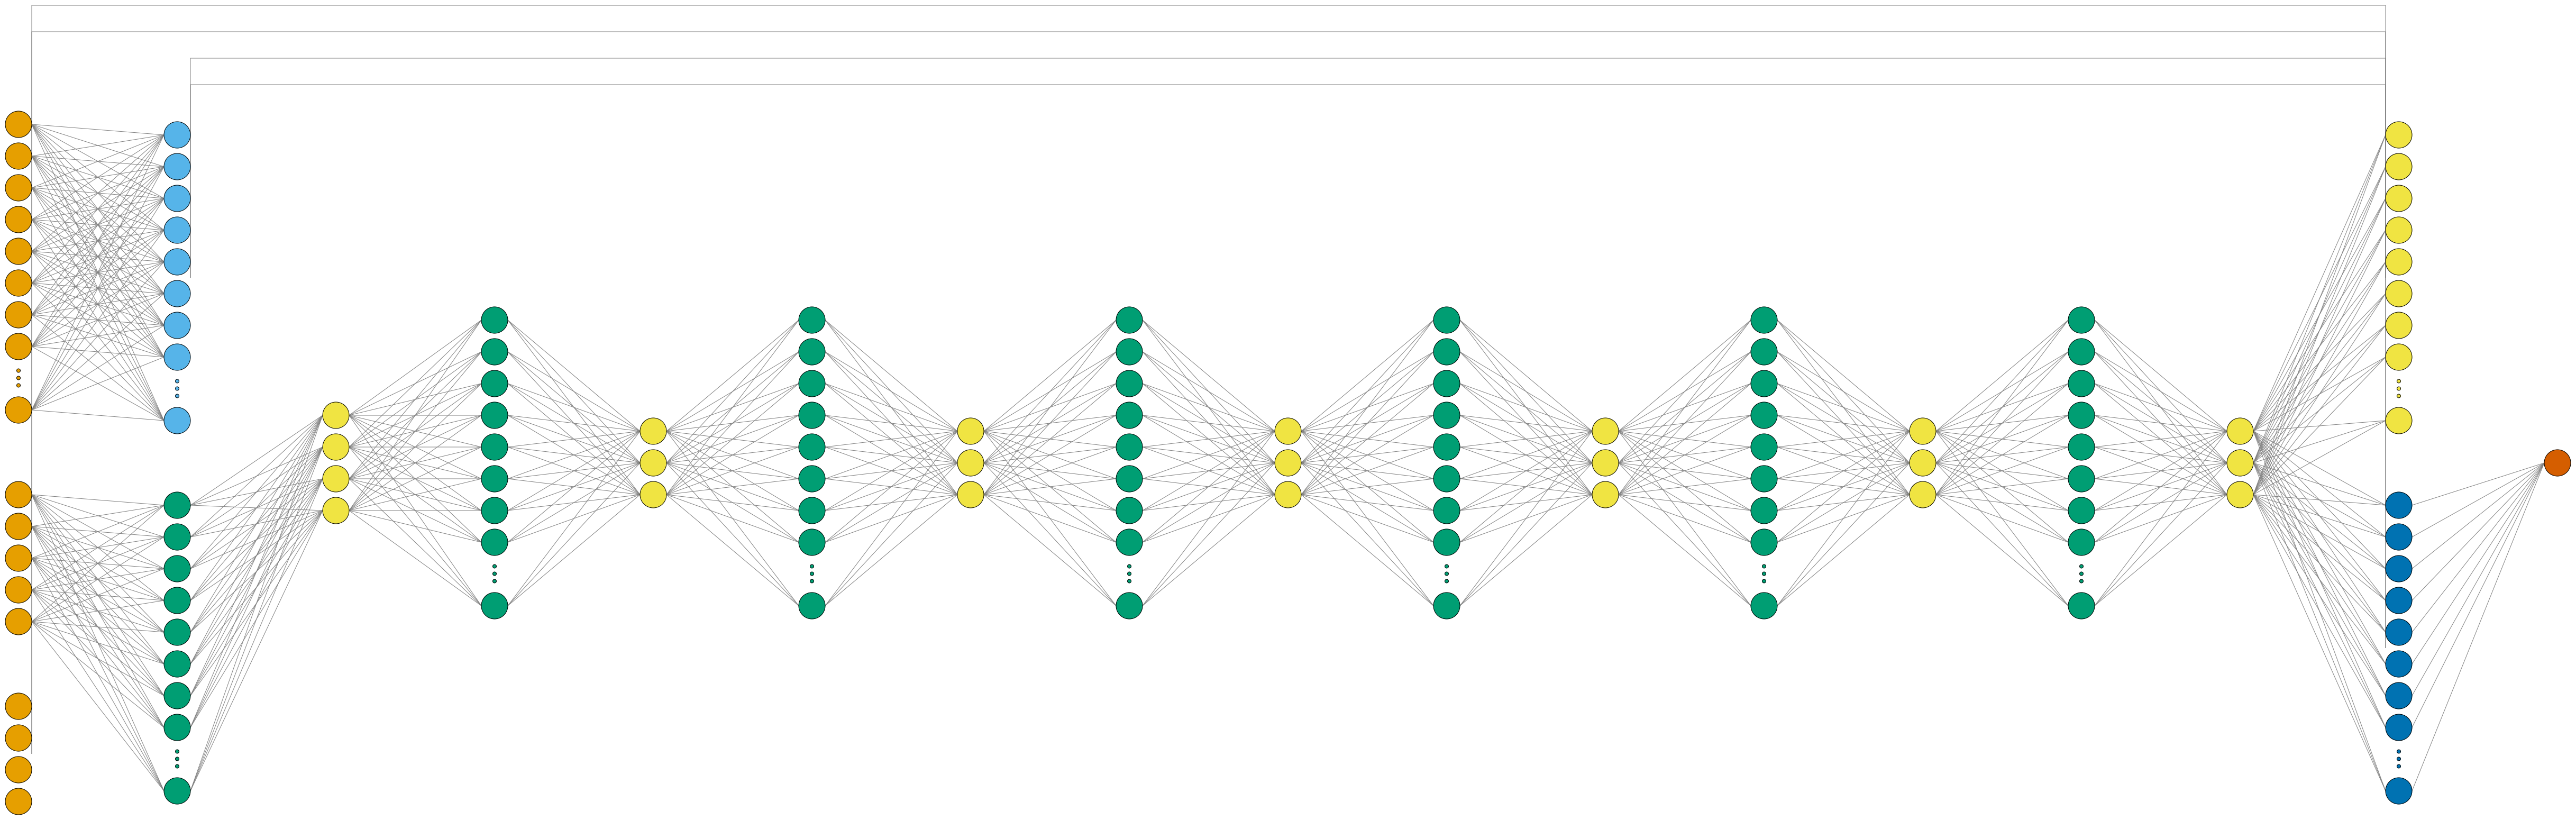

In [5]:
wrapped_model = ModifiedRevnet.VisualWrapper(ModifiedRevnet(cfg))
b, n, t1, t2, s = 20, dict_config["burn_area_resolution_days"] * 360, dict_config["lstm.input_size"], dict_config["conv1d.input_size"], len(dict_config["static_attributes"])
graph = visualtorch.render(wrapped_model, input_shape=((b,n, t1), (b, n//dict_config["burn_area_resolution_days"], t2), (b, s)), style="graph")
graph

### Excluded basin notes

03281100: NaN runoff ratio

I have not included most of the basins because it says Year is somehow missing.
I gotta diagnose it later

In [6]:
dataset = CamelsUSBurn(cfg, is_train=True, period="train" )

100%|██████████| 119/119 [00:05<00:00, 22.76it/s]


In [7]:
xarray_burn_data = dataset.f_create_monthly_xarray_burn_data()
xarray_burn_data

Caling on basin 01013500
Caling on basin 01022500
Caling on basin 01030500
Caling on basin 01031500
Caling on basin 01047000
Caling on basin 01052500
Caling on basin 01054200
Caling on basin 01055000
Caling on basin 01057000
Caling on basin 01073000
Caling on basin 01078000
Caling on basin 01118300
Caling on basin 01121000
Caling on basin 01123000
Caling on basin 01134500
Caling on basin 01137500
Caling on basin 01139000
Caling on basin 01139800
Caling on basin 01142500
Caling on basin 01144000
Caling on basin 01162500
Caling on basin 01169000
Caling on basin 01170100
Caling on basin 01181000
Caling on basin 01187300
Caling on basin 01195100
Caling on basin 01333000
Caling on basin 01350000
Caling on basin 01350080
Caling on basin 01350140
Caling on basin 01365000
Caling on basin 01411300
Caling on basin 01413500
Caling on basin 01414500
Caling on basin 01415000
Caling on basin 01423000
Caling on basin 01434025
Caling on basin 01435000
Caling on basin 01439500
Caling on basin 01440000


<xarray.Dataset> Size: 415kB
Dimensions:            (month_year: 108, features: 4)
Coordinates:
  * month_year         (month_year) int64 864B 23997 23998 23999 ... 24103 24104
    month_year_labels  (month_year) <U7 3kB '1999-10' '1999-11' ... '2008-09'
  * features           (features) <U14 224B 'frac_low' ... 'frac_inc_green'
Data variables: (12/119)
    01013500           (month_year, features) float64 3kB 0.0 0.0 ... 0.0 0.0
    01022500           (month_year, features) float64 3kB 0.0 0.0 ... 0.0 0.0
    01030500           (month_year, features) float64 3kB 0.0 0.0 ... 0.0 0.0
    01031500           (month_year, features) float64 3kB 0.0 0.0 ... 0.0 0.0
    01047000           (month_year, features) float64 3kB 0.0 0.0 ... 0.0 0.0
    01052500           (month_year, features) float64 3kB 0.0 0.0 ... 0.0 0.0
    ...                 ...
    02074500           (month_year, features) float64 3kB 0.0 0.0 ... 0.0 0.0
    02077200           (month_year, features) float64 3kB 0.0 0.0 ... 0.0 0.0
    02081500           (month_year, features) float64 3kB 0.0 0.0 ... 0.0 0.0
    02082950           (month_year, features) float64 3kB 0.0 0.0 ... 0.0 0.0
    02092500           (month_year, features) float64 3kB 0.0 0.0 ... 0.0 0.0
    02096846           (month_year, features) float64 3kB 0.0 0.0 ... 0.0 0.0

In [8]:
xarray_burn_data["01142500"]

<xarray.DataArray '01142500' (month_year: 108, features: 4)> Size: 3kB
array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
...
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])
Coordinates:
  * month_year         (month_year) int64 864B 23997 23998 23999 ... 24103 24104
    month_year_labels  (month_year) <U7 3kB '1999-10' '1999-11' ... '2008-09'
  * features           (features) <U14 224B 'frac_low' ... 'frac_inc_green'